### 1.4.4.3. Homogeneous Equations with Constant Coefficients

$$
ay'' + by' + cy = 0 \;\xrightarrow{\,y=e^{mx}\,}\; am^2 + bm + c = 0 \ (\text{auxiliary equation}),
$$

$$
\text{roots} \to
\begin{cases}
\text{distinct real } m_1, m_2: & y = c_1 e^{m_1 x} + c_2 e^{m_2 x} \\
\text{repeated } m_1: & y = c_1 e^{m_1 x} + c_2 x e^{m_1 x} \\
\text{complex } \alpha \pm i\beta: & y = e^{\alpha x}(c_1 \cos\beta x + c_2 \sin\beta x)
\end{cases}.
$$

**Explanation:**

For constant coefficients, trying $y = e^{mx}$ reduces the differential equation to the algebraic **auxiliary (characteristic) equation** $am^2 + bm + c = 0$. Its roots determine the [fundamental set](./01_preliminary_theory_of_linear_equations.ipynb): two distinct real roots give two exponentials; a repeated root needs the extra factor $x$ (from [reduction of order](./02_reduction_of_order.ipynb)); complex conjugate roots $\alpha \pm i\beta$ give a decaying/growing oscillation via Euler's formula. The sign of the real parts decides stability — the same characteristic-root analysis the control track uses for [linear systems](../08_Systems_of_Linear_First_Order_ODEs/02_homogeneous_systems_eigenvalue_method.ipynb).

**Properties:**
- The real part of each root sets growth ($>0$) or decay ($<0$); the imaginary part sets oscillation frequency.
- An $n$th-order equation gives a degree-$n$ characteristic polynomial with $n$ roots (counted with multiplicity).

**Numerical Example:**

**Three root types.**

(a) $2y'' - 5y' - 3y = 0$: auxiliary $2m^2 - 5m - 3 = (2m+1)(m-3) = 0$, roots $m = -\tfrac12, 3$, so $y = c_1 e^{-x/2} + c_2 e^{3x}$.

(b) $y'' - 10y' + 25y = 0$: auxiliary $(m-5)^2 = 0$, repeated root $m = 5$, so $y = c_1 e^{5x} + c_2 x e^{5x}$.

(c) $y'' + 4y' + 7y = 0$: auxiliary $m^2 + 4m + 7 = 0$, roots $m = -2 \pm \sqrt{3}\,i$, so $y = e^{-2x}\!\left(c_1 \cos\sqrt{3}\,x + c_2 \sin\sqrt{3}\,x\right)$.

**IVP.** Solve $4y'' + 4y' + 17y = 0$, $y(0) = -1$, $y'(0) = 2$. Auxiliary $4m^2 + 4m + 17 = 0$ gives $m = -\tfrac12 \pm 2i$, so $y = e^{-x/2}(c_1\cos 2x + c_2\sin 2x)$. Then $y(0) = c_1 = -1$, and differentiating and using $y'(0) = 2$ gives $2c_2 + \tfrac12 = 2$, so $c_2 = \tfrac34$:

$$
y = e^{-x/2}\!\left(-\cos 2x + \tfrac34 \sin 2x\right),
$$

an oscillation decaying to $0$.

In [1]:
import sympy as sp

x, m = sp.symbols("x m")
y = sp.Function("y")

cases = {
    "2y'' - 5y' - 3y = 0": 2 * m**2 - 5 * m - 3,
    "y'' - 10y' + 25y = 0": m**2 - 10 * m + 25,
    "y'' + 4y' + 7y = 0": m**2 + 4 * m + 7,
}
for label, auxiliary in cases.items():
    print(f"{label:22} roots = {sp.roots(auxiliary, m)}")

ivp = sp.dsolve(sp.Eq(4 * y(x).diff(x, 2) + 4 * y(x).diff(x) + 17 * y(x), 0), y(x),
                ics={y(0): -1, y(x).diff(x).subs(x, 0): 2})
print("IVP solution:", ivp.rhs)

2y'' - 5y' - 3y = 0    roots = {3: 1, -1/2: 1}
y'' - 10y' + 25y = 0   roots = {5: 2}
y'' + 4y' + 7y = 0     roots = {-2 - sqrt(3)*I: 1, -2 + sqrt(3)*I: 1}
IVP solution: (3*sin(2*x)/4 - cos(2*x))*exp(-x/2)


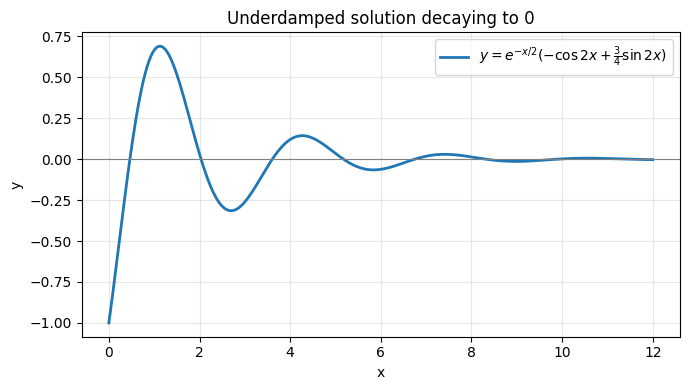

In [2]:
import numpy as np
import matplotlib.pyplot as plt

time = np.linspace(0, 12, 300)
solution = np.exp(-time / 2) * (-np.cos(2 * time) + 0.75 * np.sin(2 * time))

plt.figure(figsize=(7, 4))
plt.plot(time, solution, linewidth=2, label=r"$y = e^{-x/2}(-\cos 2x + \frac{3}{4} \sin 2x)$")
plt.axhline(0, color="gray", linewidth=0.8)
plt.xlabel("x"); plt.ylabel("y"); plt.title("Underdamped solution decaying to 0")
plt.legend(); plt.grid(True, alpha=0.3); plt.tight_layout()
plt.show()

**References:**

[📘 Zill, D. G. (2016). *A First Course in Differential Equations with Modeling Applications* (11th ed.). Cengage Learning.](https://www.cengage.com/c/a-first-course-in-differential-equations-with-modeling-applications-11e-zill/9781305965720/)

---

[⬅️ Previous: Reduction of Order](./02_reduction_of_order.ipynb) | [Next: Undetermined Coefficients ➡️](./04_undetermined_coefficients.ipynb)